In [14]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn import datasets
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, silhouette_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

## !pip install cartopy

* 지리적 데이터를 처리하고 시각화하기 위한 강력한 Python 라이브러리
* 지도 시각화, 공간 데이터 플롯팅, 그리고 다양한 투영법을 사용하여 데이터를 표현 
* 주로 기후 데이터나 지리 데이터를 시각화하는 데 사용
* Cartography + Python

In [15]:
import datetime as dt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial import distance

In [16]:
birdata = pd.read_csv('../../data/bird_tracking.csv')
birdata.head()

,altitude,date_time,device_info_serial,direction,latitude,longitude,speed_2d,bird_name
0,71,2013-08-15 00:18:08+00,851,NaN,49.419860,2.120733,0.191484,Eric
1,68,2013-08-15 00:48:07+00,851,NaN,49.419880,2.120746,2.739698,Eric
2,68,2013-08-15 01:17:58+00,851,NaN,49.420310,2.120885,0.360099,Eric
3,73,2013-08-15 01:47:51+00,851,NaN,49.420359,2.120859,0.039658,Eric
4,69,2013-08-15 02:17:42+00,851,NaN,49.420331,2.120887,0.107988,Eric


In [17]:
birdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61931 entries, 0 to 61930
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   altitude            61931 non-null  int64  
 1   date_time           61931 non-null  object 
 2   device_info_serial  61931 non-null  int64  
 3   direction           0 non-null      float64
 4   latitude            61931 non-null  float64
 5   longitude           61931 non-null  float64
 6   speed_2d            61488 non-null  float64
 7   bird_name           61931 non-null  object 
dtypes: float64(4), int64(2), object(2)
memory usage: 3.8+ MB


In [18]:
## Eric 의 비행 시작날짜와 마지막 날짜

ix = birdata.bird_name == 'Eric'
date = birdata.date_time[ix]
print(date[:1])     # 첫번째 행
print(date[-1:])    # 마지막 행
print('=' * 60)
print(ix)

0    2013-08-15 00:18:08+00
Name: date_time, dtype: object
19797    2014-04-30 23:51:29+00
Name: date_time, dtype: object
0         True
1         True
2         True
3         True
4         True
         ...  
61926    False
61927    False
61928    False
61929    False
61930    False
Name: bird_name, Length: 61931, dtype: bool


In [19]:
# 첫번째 행을 datetime의로 파싱하는 연습

date_str = birdata.date_time[0]   # 문자열을 날짜와 시간으로 파싱
dt.datetime.strptime(date_str[:-3],'%Y-%m-%d %H:%M:%S')# 문자열의 마지막 3글자를 제거 (밀리초 제거)

# 문자열을 날자와 시가느로 파싱
# 문자열의 마지막 3글자 제거 (밀리초 제거)
# strptime : string parse time

datetime.datetime(2013, 8, 15, 0, 18, 8)

In [20]:
birdata['timestamp'] = birdata['date_time'].apply(lambda x: dt.datetime.strptime(x[:-3],'%Y-%m-%d %H:%M:%S'))
birdata.head()

,altitude,date_time,device_info_serial,direction,latitude,longitude,speed_2d,bird_name,timestamp
0,71,2013-08-15 00:18:08+00,851,NaN,49.419860,2.120733,0.191484,Eric,2013-08-15 00:18:08
1,68,2013-08-15 00:48:07+00,851,NaN,49.419880,2.120746,2.739698,Eric,2013-08-15 00:48:07
2,68,2013-08-15 01:17:58+00,851,NaN,49.420310,2.120885,0.360099,Eric,2013-08-15 01:17:58
3,73,2013-08-15 01:47:51+00,851,NaN,49.420359,2.120859,0.039658,Eric,2013-08-15 01:47:51
4,69,2013-08-15 02:17:42+00,851,NaN,49.420331,2.120887,0.107988,Eric,2013-08-15 02:17:42


In [21]:
birdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61931 entries, 0 to 61930
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   altitude            61931 non-null  int64         
 1   date_time           61931 non-null  object        
 2   device_info_serial  61931 non-null  int64         
 3   direction           0 non-null      float64       
 4   latitude            61931 non-null  float64       
 5   longitude           61931 non-null  float64       
 6   speed_2d            61488 non-null  float64       
 7   bird_name           61931 non-null  object        
 8   timestamp           61931 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 4.3+ MB


In [22]:
# 중복 제거한 새의 이름 출력
bird_names = pd.unique(birdata.bird_name)
print(bird_names)

['Eric' 'Nico' 'Sanne']


In [23]:
# Eric의 비행 경과 시간 계산 (행마다)
times = birdata.timestamp[birdata.bird_name == 'Eric']
elapsed = [time - times[0] for time in times]   # 첫번째 행에서 얼마나 경과되었나 계산
elapsed

## Eric 데이터의 시작포인트부터 각각의 포인트까지 경과시간
## times 리스트의 각 요소에서 첫 번째 요소를 뺌 -> 결과는 timedelta 리스트로 


## groupby와 transform을 이용하여 새로운 컬럼에 경과시간을 넣을 수도 있다.

[Timedelta('0 days 00:00:00'),
 Timedelta('0 days 00:29:59'),
 Timedelta('0 days 00:59:50'),
 Timedelta('0 days 01:29:43'),
 Timedelta('0 days 01:59:34'),
 Timedelta('0 days 02:29:30'),
 Timedelta('0 days 02:44:25'),
 Timedelta('0 days 02:59:19'),
 Timedelta('0 days 03:14:27'),
 Timedelta('0 days 03:29:40'),
 Timedelta('0 days 03:45:31'),
 Timedelta('0 days 04:00:32'),
 Timedelta('0 days 04:15:45'),
 Timedelta('0 days 04:30:58'),
 Timedelta('0 days 04:46:37'),
 Timedelta('0 days 05:02:01'),
 Timedelta('0 days 05:16:56'),
 Timedelta('0 days 05:31:50'),
 Timedelta('0 days 05:46:48'),
 Timedelta('0 days 06:01:46'),
 Timedelta('0 days 06:16:42'),
 Timedelta('0 days 06:31:35'),
 Timedelta('0 days 06:46:32'),
 Timedelta('0 days 07:01:27'),
 Timedelta('0 days 07:16:23'),
 Timedelta('0 days 07:31:21'),
 Timedelta('0 days 07:46:48'),
 Timedelta('0 days 08:01:44'),
 Timedelta('0 days 08:16:39'),
 Timedelta('0 days 08:31:43'),
 Timedelta('0 days 08:46:55'),
 Timedelta('0 days 09:01:59'),
 Timedel

Text(0, 0.5, 'Elapsed(days)')

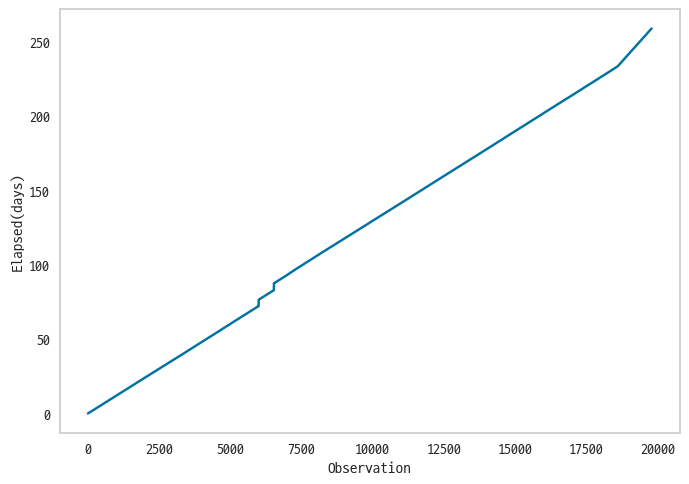

In [24]:
# 관측 순서에 따른 경과 일수 시각
plt.plot(np.array(elapsed) / dt.timedelta(days=1))   # timedelta를 일(day) 단위 숫자로 변환
plt.grid(False)
plt.xlabel('Observation')   # 관측횟수
plt.ylabel('Elapsed(days)') # 경과시간(days)

In [25]:
new_birdata = birdata[['bird_name', 'timestamp']].copy()
new_birdata['timedelta'] = new_birdata.groupby('bird_name')['timestamp'].transform(lambda x: x - x.iloc[0])
new_birdata['elapsed'] = new_birdata['timedelta'] / np.timedelta64(1, 'D')
new_birdata

,bird_name,timestamp,timedelta,elapsed
0,Eric,2013-08-15 00:18:08,0 days 00:00:00,0.000000
1,Eric,2013-08-15 00:48:07,0 days 00:29:59,0.020822
2,Eric,2013-08-15 01:17:58,0 days 00:59:50,0.041551
3,Eric,2013-08-15 01:47:51,0 days 01:29:43,0.062303
4,Eric,2013-08-15 02:17:42,0 days 01:59:34,0.083032
...,...,...,...,...
61926,Sanne,2014-04-30 22:00:08,258 days 21:59:00,258.915972
61927,Sanne,2014-04-30 22:29:57,258 days 22:28:49,258.936678
61928,Sanne,2014-04-30 22:59:52,258 days 22:58:44,258.957454
61929,Sanne,2014-04-30 23:29:43,258 days 23:28:35,258.978183


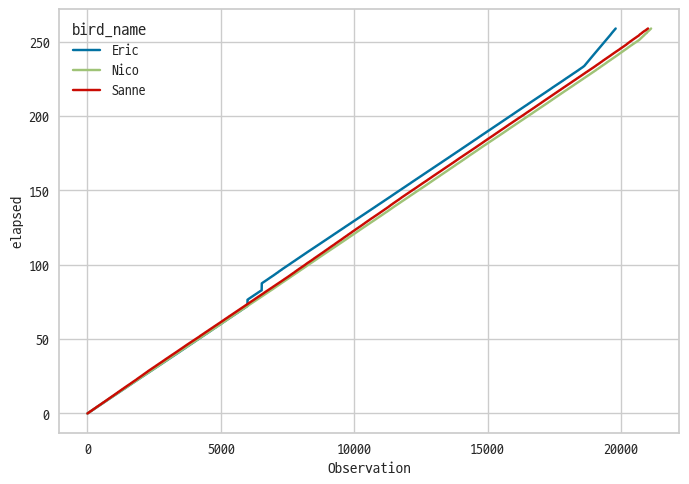

In [27]:
sns.lineplot(data=new_birdata, x=new_birdata.groupby('bird_name').cumcount(), y='elapsed', hue='bird_name')
plt.xlabel('Observation')
plt.show()

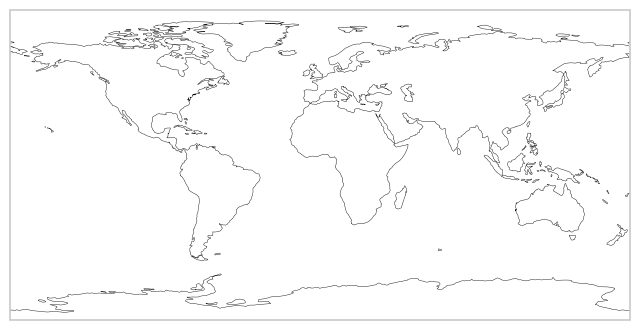

In [29]:
# 지도 생성 (Plate Carrée 투영)

ax = plt.axes(projection=ccrs.PlateCarree())   # Plate Carrée 투영법으로 지도를 생성 (지구를 평면으로 투영)
ax.coastlines()  ## 지도에 해안선 표시
plt.show()

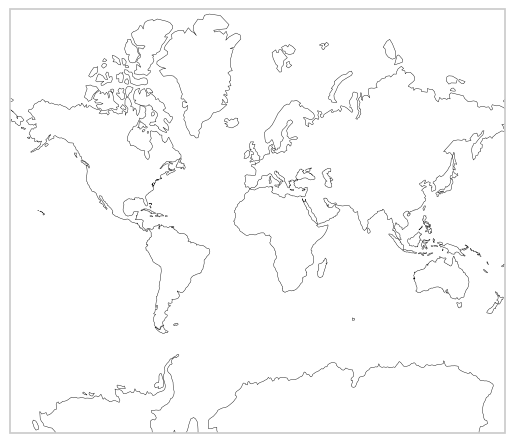

In [30]:
# 지도 생성 (Mercator 투영)

ax = plt.axes(projection=ccrs.Mercator())  # Mercator 투영법으로 지도를 생성 (항해지도)
ax.coastlines()  ## 지도에 해안선 표시
plt.show()

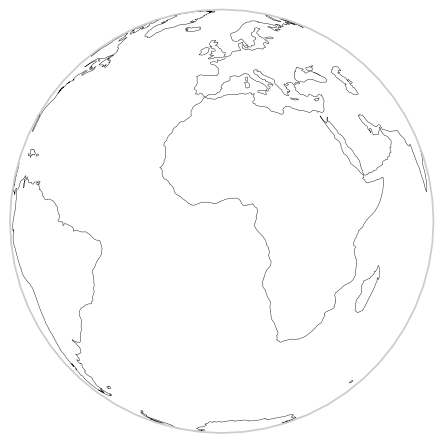

In [31]:
# 지도 생성 (Orthographic 투영)

ax = plt.axes(projection=ccrs.Orthographic())  # Orthographic 투영법으로 지도를 생성 (지구본 느낌)
ax.coastlines()  ## 지도에 해안선 표시
plt.show()

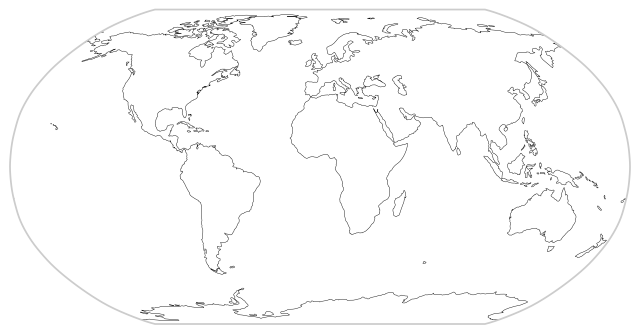

In [32]:
# 지도 생성 (Robinson 투영)

ax = plt.axes(projection=ccrs.Robinson())  # Robinson 투영법으로 지도를 생성 (세계지도용)
ax.coastlines()  ## 지도에 해안선 표시
plt.show()

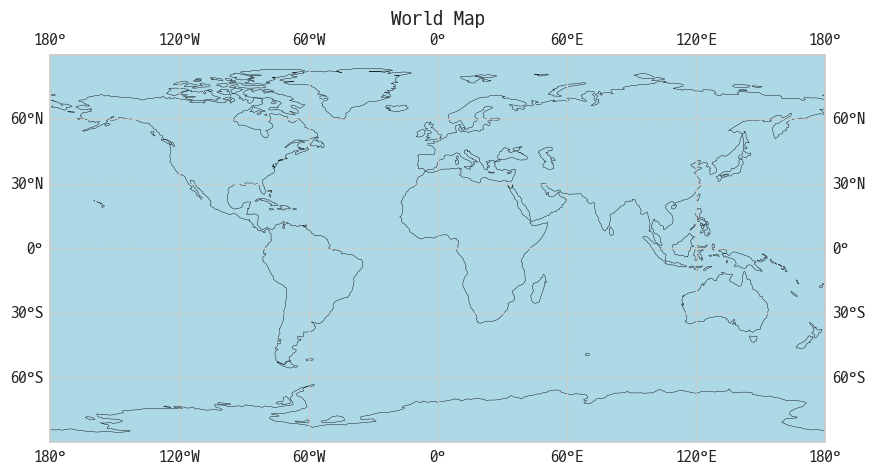

In [38]:
# 지도 스타일 개선

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) 

# 배경 색상 설정
ax.set_facecolor('lightblue')

# 해안선 추가
ax.coastlines()

# 그리드 라인 추가 (위경도 격자 )
ax.gridlines(draw_labels=True, linestyle='--')

# 축 레이블 설정
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# 타이틀 추가
plt.title('World Map', fontsize=15)

plt.show()

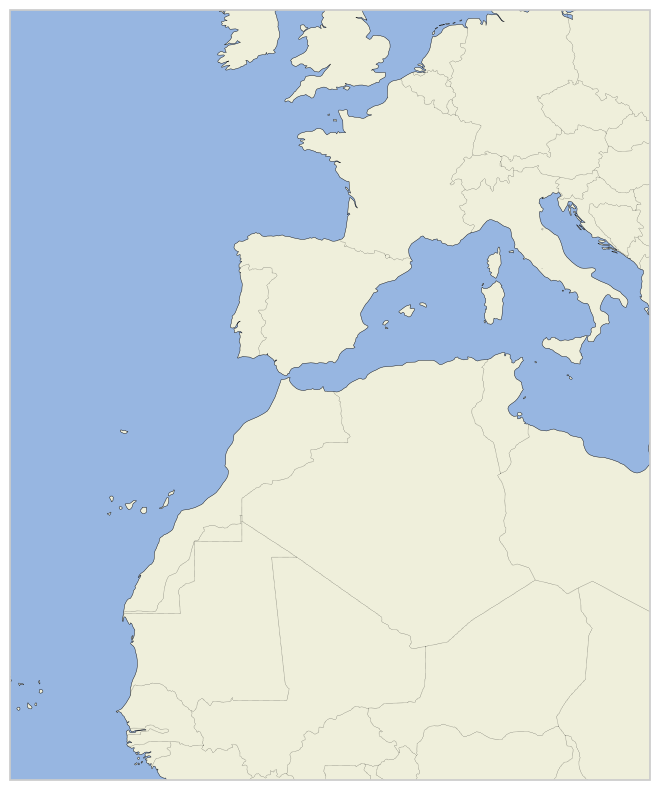

In [35]:
# Mercator 투영
plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.Mercator())  # 이동 경로에 자주 쓰이는 Mercator 투영

ax.set_extent((-25.0, 20.0, 52.0, 10.0))  ## 경도와 위도의 범위 설정
ax.add_feature(cfeature.LAND) ## 육지 추가
ax.add_feature(cfeature.OCEAN)  ##  바다 추가
ax.add_feature(cfeature.COASTLINE)  ##  해안선 추가
ax.add_feature(cfeature.BORDERS, linestyle=':');  ## 국경선 추가

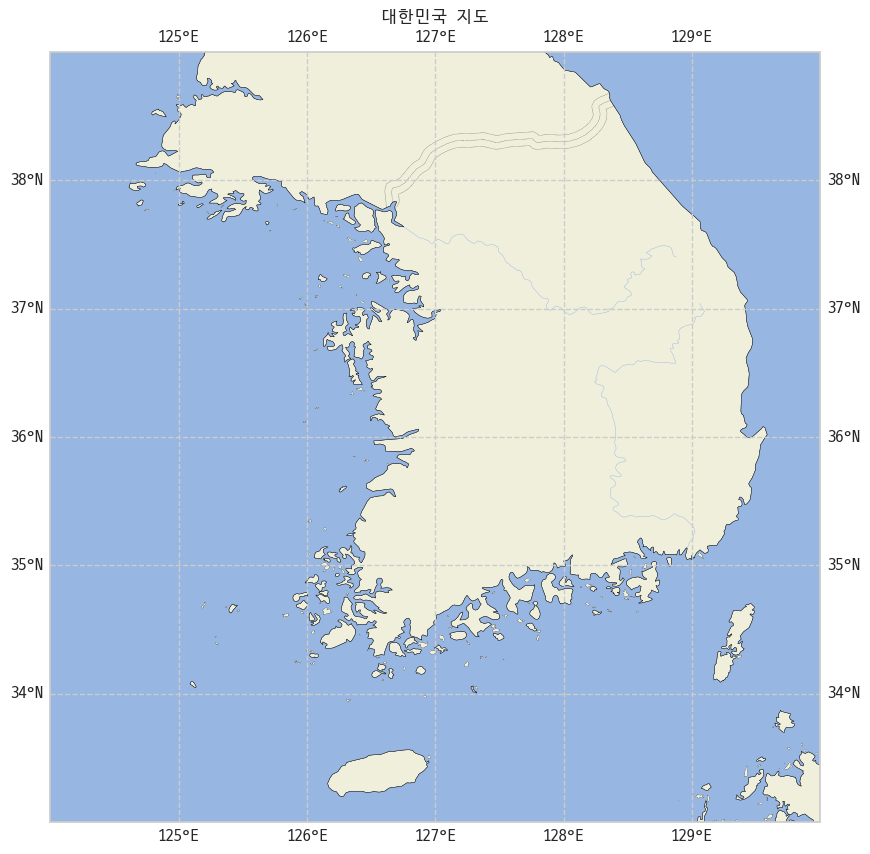

In [ ]:
######### sample : 우리나라 지도

extent = [124, 130, 33, 39] # 경도, 위도 순

# 지도 생성
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent)

# 배경 지도 추가
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.RIVERS)  # 강을 추가

# 그리드 라인 및 레이블 추가
ax.gridlines(draw_labels=True, linestyle='--')

# 타이틀 추가
plt.title('대한민국 지도')

# 플롯 보이기
plt.show()

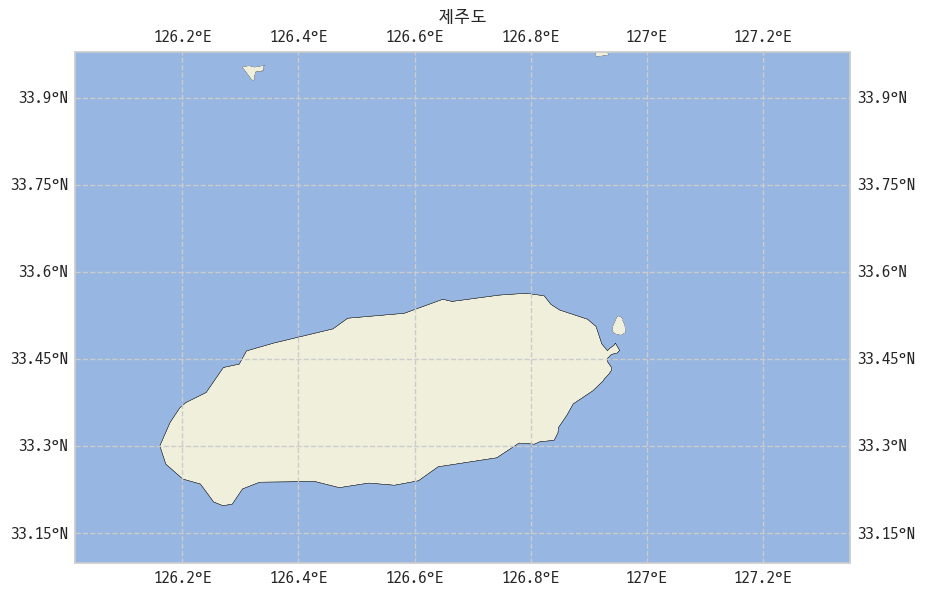

In [ ]:
######### sample : 제주도

extent = [126.0152, 127.3504, 33.0989, 33.9799]

# 지도 생성
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent)

# 배경 지도 추가
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.RIVERS)  # 강을 추가

# 그리드 라인 및 레이블 추가
ax.gridlines(draw_labels=True, linestyle='--')

# 타이틀 추가
plt.title('제주도')

# 플롯 보이기
plt.show()

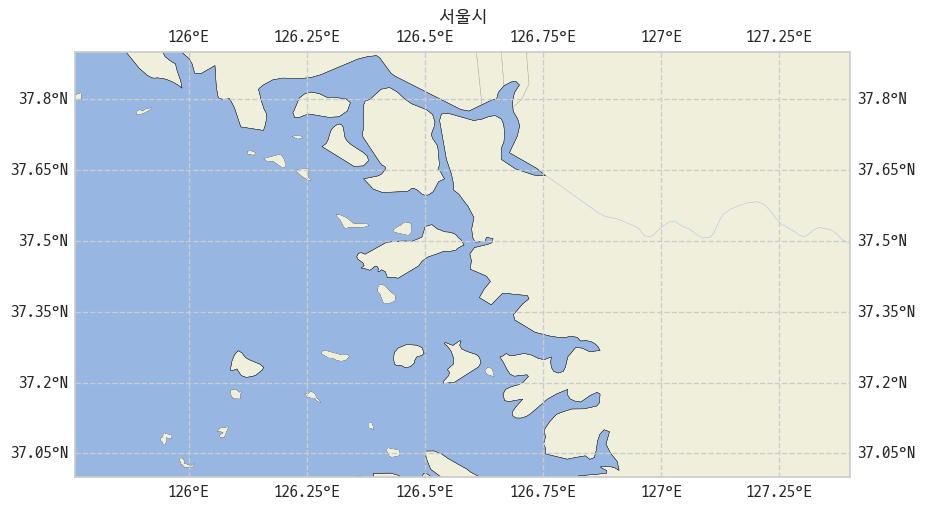

In [41]:
######### sample : 서울
## 서울특별시는 북위 약 37.4~37.7도, 동경 약 126.7~127.2도 범위

extent = [125.76, 127.4, 37.00, 37.90]

# 지도 생성
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent)

# 배경 지도 추가
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.RIVERS)  # 강을 추가

# 그리드 라인 및 레이블 추가
ax.gridlines(draw_labels=True, linestyle='--')

# 타이틀 추가
plt.title('서울시')

# 플롯 보이기
plt.show()

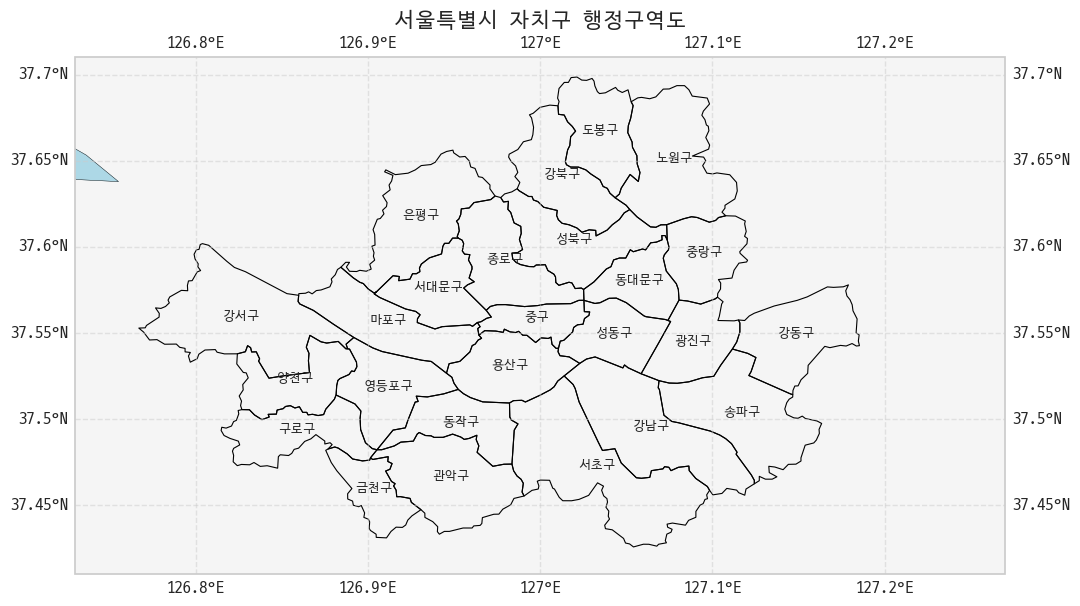

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# 1. 서울시 위경도 범위 설정 (Extent)
# [최소 경도, 최대 경도, 최소 위도, 최대 위도]
extent = [126.73, 127.27, 37.41, 37.71]

# 2. 서울시 구 경계 데이터 로드 (GeoJSON)
# 오픈 소스로 제공되는 서울 행정구역 JSON을 활용합니다.
url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
seoul_gu = gpd.read_file(url)

# 지도 생성
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent)

# 배경 및 기본 지형 추가
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, color='whitesmoke')
ax.add_feature(cfeature.OCEAN, color='#ADD8E6') # 추천드린 LightBlue 계열

# 3. 서울시 구 경계 그리기
# GeoPandas 데이터를 Cartopy 레이어에 추가합니다.
for _, row in seoul_gu.iterrows():
    geom = row['geometry']
    ax.add_geometries([geom], ccrs.y(), 
                      facecolor='none', edgecolor='black', linewidth=0.8)
    
    # 구 이름 표시 (선택 사항)
    center = geom.centroid
    ax.text(center.x, center.y, row['name'], 
            transform=ccrs.PlateCarree(), ha='center', fontsize=9)

# 그리드 라인 및 타이틀
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
plt.title('서울특별시 자치구 행정구역도', fontsize=15)

plt.show()

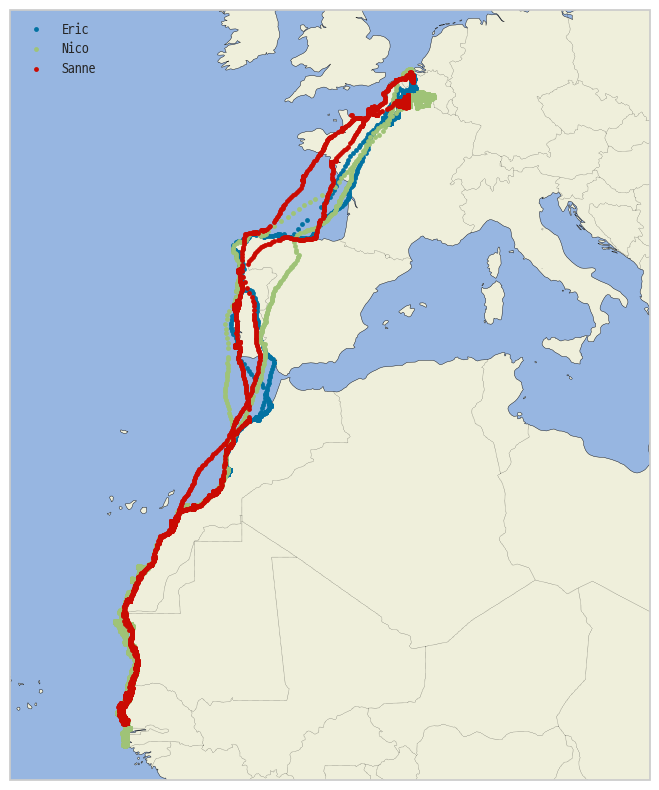

In [47]:
# 모든 새의 이동 경로 표시

extent = [-25.0, 20.0, 52.0, 10.0]

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.Mercator())
# ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

for name in bird_names:
    ix = birdata['bird_name'] == name
    x, y = birdata.longitude[ix], birdata.latitude[ix]  # 경도, 위도 좌표 추출
    ax.plot(x, y, '.', transform=ccrs.Geodetic(), label=name)  # 해당 경도, 위도에 점 표시
    
plt.legend(loc='upper left')
plt.show()

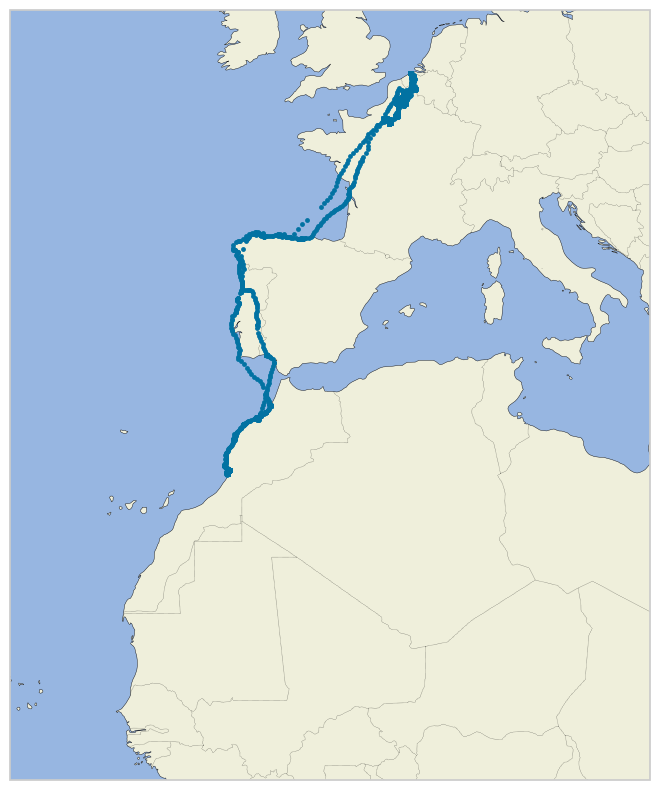

In [ ]:
# 모든 새의 이동 경로 표시

extent = [-25.0, 20.0, 52.0, 10.0]

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.Mercator())
# ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

ix = birdata['bird_name'] == 'Eric' # Eric만 추출
x, y = birdata.longitude[ix], birdata.latitude[ix]  # 경도, 위도 좌표 추출
ax.plot(x, y, '.', transform=ccrs.Geodetic(), label=name)  # 해당 경도, 위도에 점 표시
    
plt.show()

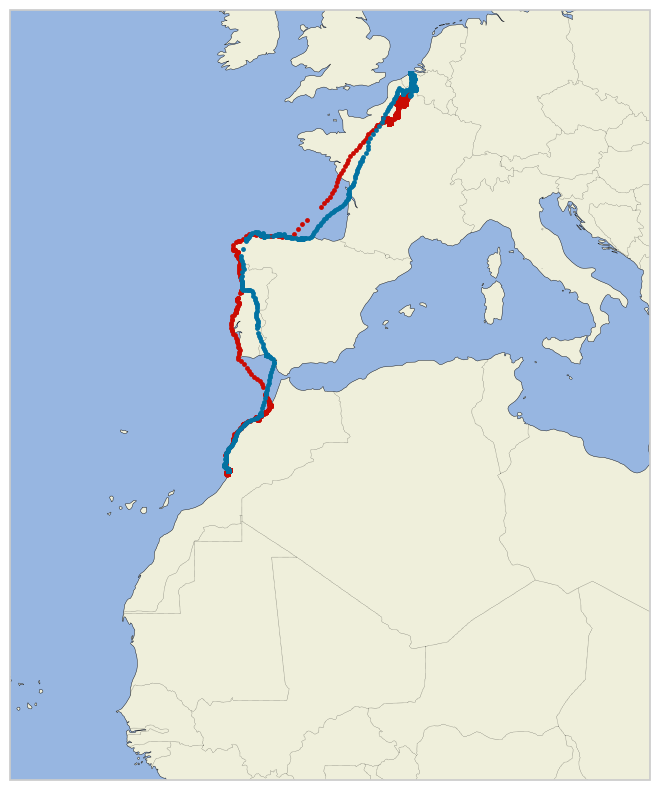

In [ ]:
# Eric의 이동경로

extent = [-25.0, 20.0, 52.0, 10.0]

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(extent)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

bird_names = pd.unique(birdata.bird_name)
ix = birdata['bird_name'] == 'Eric'
x, y = birdata.longitude[ix], birdata.latitude[ix]
ax.plot(x[0:17000], y[0:17000], '.', transform=ccrs.Geodetic(), color='r')          # 내려갈 때 (정확한 행을 찾은 것은 아님)
ax.plot(x[17000:19797], y[17000:19797], '.', transform=ccrs.Geodetic(), color='b')  # 올라갈 때
plt.show()

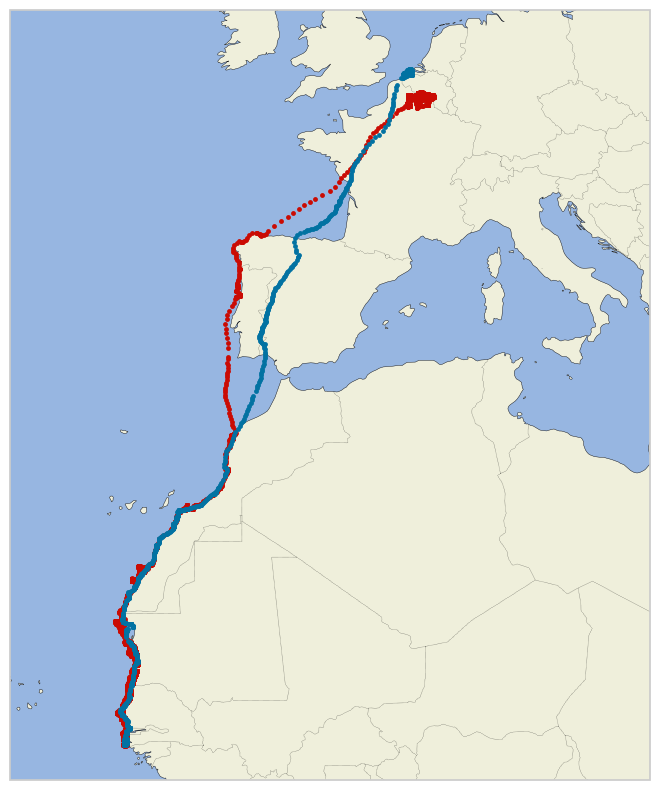

In [ ]:
# Nico의 이동경로

extent = [-25.0, 20.0, 52.0, 10.0]

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(extent)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

bird_names = pd.unique(birdata.bird_name)
ix = birdata['bird_name'] == 'Nico'
x, y = birdata.longitude[ix], birdata.latitude[ix]
ax.plot(x[0:19000], y[0:19000], '.', transform=ccrs.Geodetic(), color='r')          # 행번호에 주의 할 것
ax.plot(x[19000:21120], y[19000:21120], '.', transform=ccrs.Geodetic(), color='b')  # 행번호가 전부 변경되었다
plt.show()

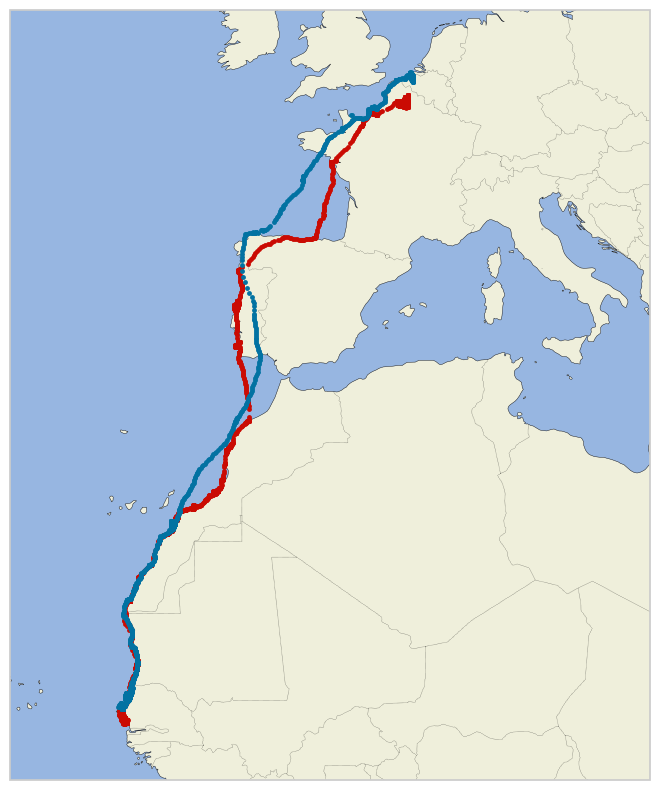

In [ ]:
# Sanne 의 이동경로

extent = [-25.0, 20.0, 52.0, 10.0]

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(extent)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

bird_names = pd.unique(birdata.bird_name)
ix = birdata['bird_name'] == 'Sanne'
x, y = birdata.longitude[ix], birdata.latitude[ix]
ax.plot(x[0:15000], y[0:15000], '.', transform=ccrs.Geodetic(), color='r')          # 정확한 행번호는 아님
ax.plot(x[15000:21000], y[15000:21000], '.', transform=ccrs.Geodetic(), color='b')  # 정확한 행번호는 아님
plt.show()